# **Uncovering Hidden Country Segments for Global Development Strategy**

# Problem Understanding

This problem focuses on using unsupervised learning to analyze socio-economic data and group countries into similar clusters, enabling more targeted and efficient development strategies.

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Read df
url = "https://drive.google.com/uc?id=1SWUXaC78y2lnahVnUwBPmyXOicJW41Po"
df = pd.read_csv(url)

df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [ ]:
# Check info of df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [ ]:
# Check null values
df.isnull().sum()

,0
country,0
child_mort,0
exports,0
health,0
imports,0
income,0
inflation,0
life_expec,0
total_fer,0
gdpp,0


In [ ]:
# Check df shape
df.shape

(167, 10)

In [ ]:
# Summary statistics
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# Data Preprocessing & EDA

In [ ]:
# Handling outliers(IQR method)
def cap_outliers(df, cols):
    for col in cols:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] < lower, lower,
                           np.where(df[col] > upper, upper, df[col]))
    return df

num_cols = df.select_dtypes(include=np.number).columns
df = cap_outliers(df, num_cols)

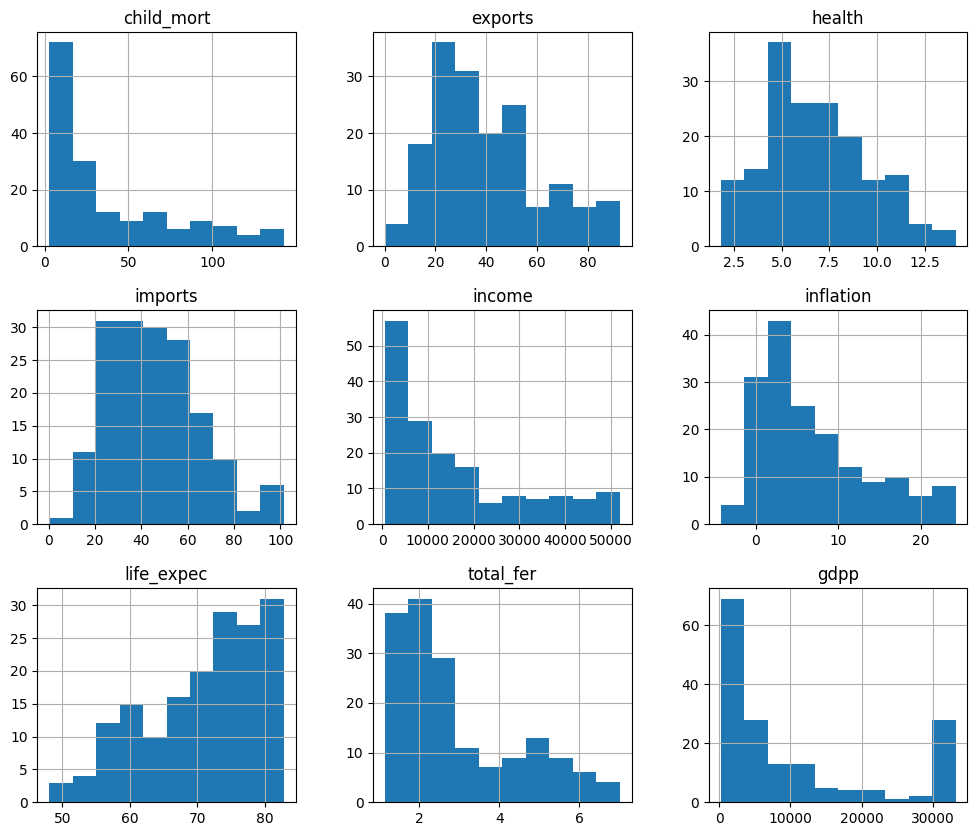

In [ ]:
# Visualizing Data Distributions
df.hist(figsize=(12,10))
plt.show()

In [ ]:
# Skewness Analysis
df[num_cols].skew().sort_values(ascending=False)

,0
child_mort,1.197712
gdpp,1.115232
income,1.040602
inflation,0.966714
total_fer,0.941084
exports,0.698211
imports,0.673252
health,0.480173
life_expec,-0.660644


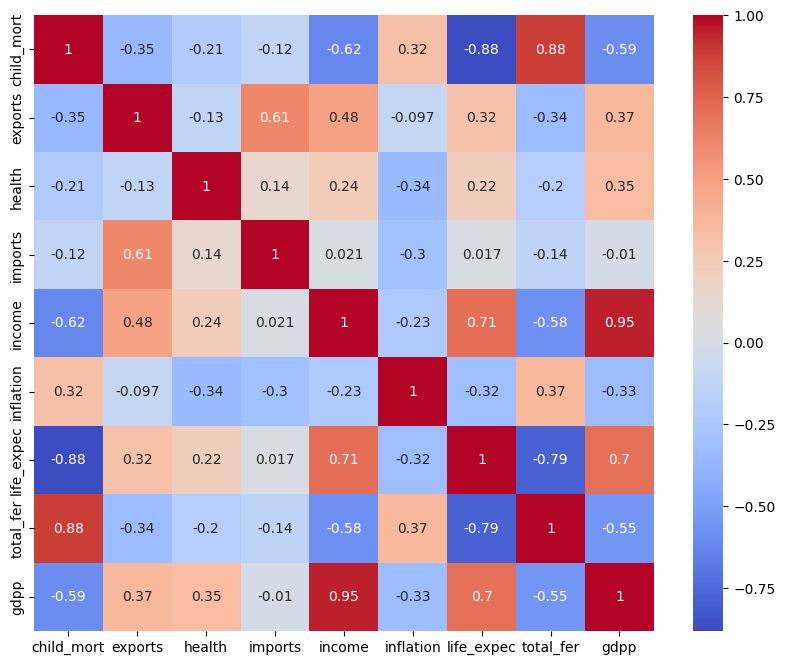

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

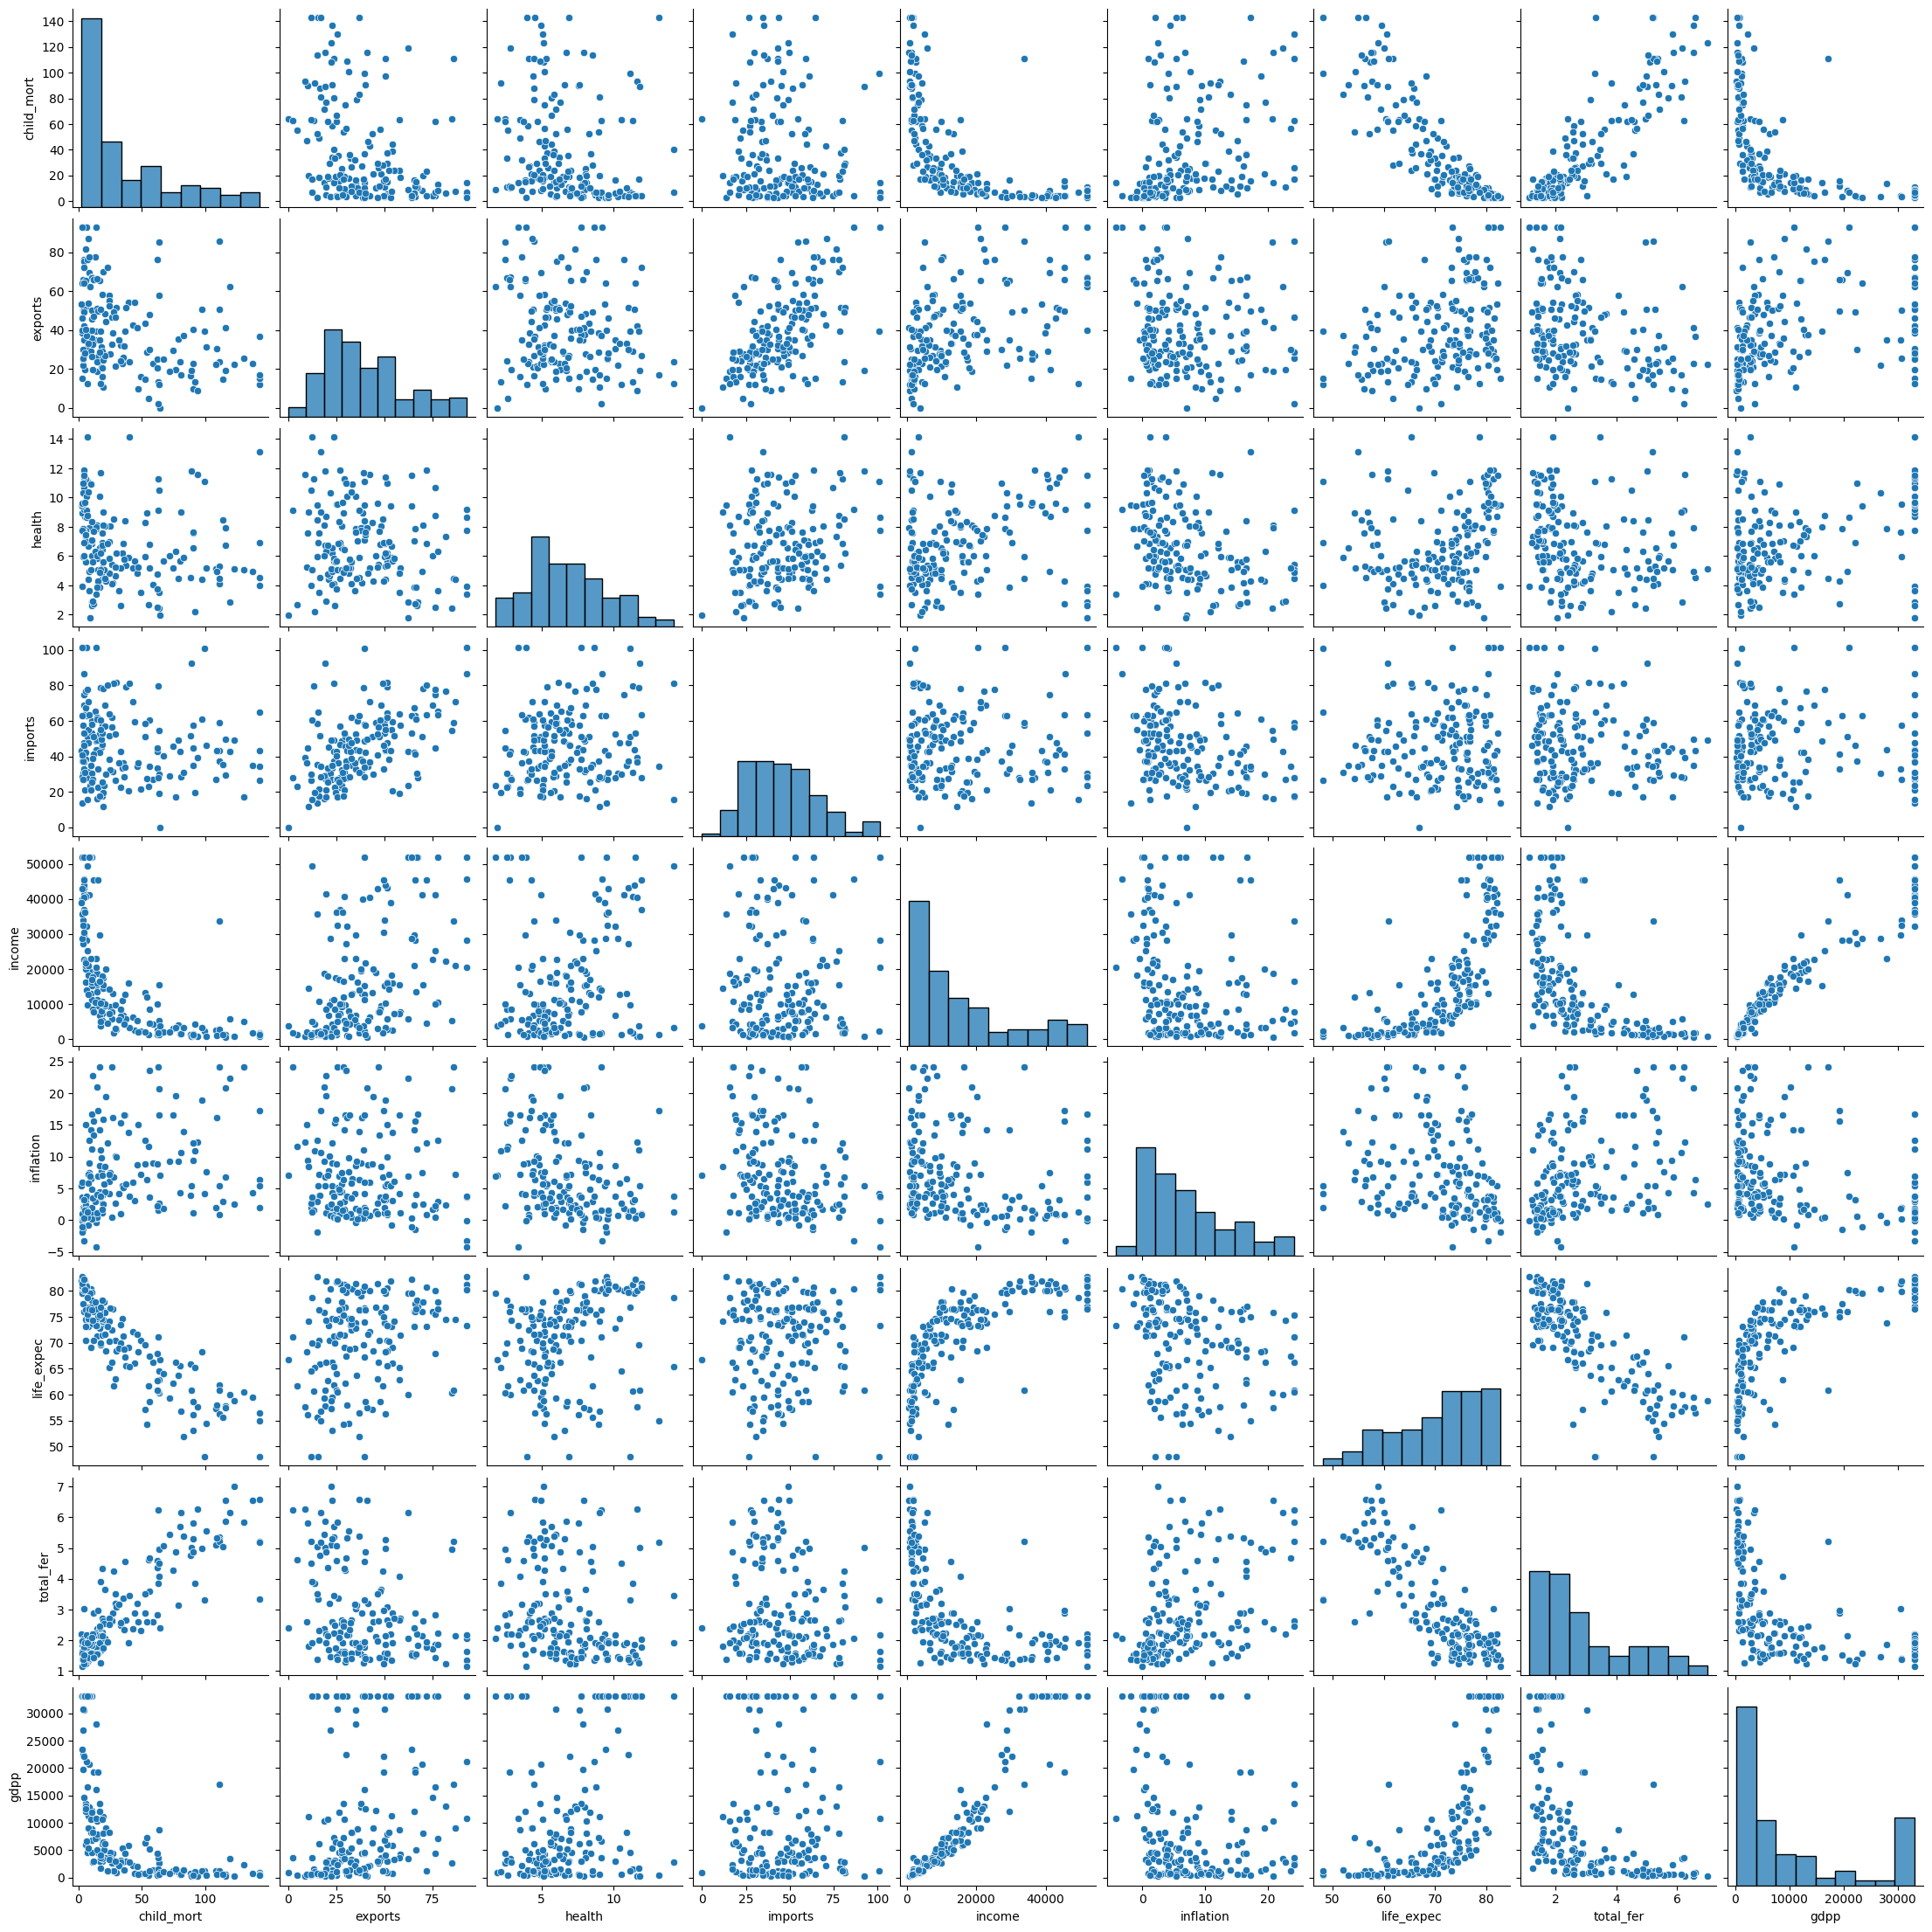

In [ ]:
# Pairplot
sns.pairplot(df[num_cols])
plt.show()

In [ ]:
# Top 5(Highest income)
df.sort_values(by='income', ascending=False)[['country','income']].head()

,country,income
23,Brunei,51967.5
133,Singapore,51967.5
145,Switzerland,51967.5
157,United Arab Emirates,51967.5
123,Qatar,51967.5


In [ ]:
# Bottom 5(Lowest income)
df.sort_values(by='income')[['country','income']].head()

,country,income
37,"Congo, Dem. Rep.",609.0
88,Liberia,700.0
26,Burundi,764.0
112,Niger,814.0
31,Central African Republic,888.0


In [ ]:
# Top 5(Highest child_mort)
df.sort_values(by='child_mort', ascending=False)[['country','child_mort']].head()

,country,child_mort
31,Central African Republic,142.875
32,Chad,142.875
66,Haiti,142.875
132,Sierra Leone,142.875
97,Mali,137.000


In [ ]:
# Bottom 5(Lowest child_mort)
df.sort_values(by='child_mort')[['country','child_mort']].head()

,country,child_mort
68,Iceland,2.6
91,Luxembourg,2.8
133,Singapore,2.8
53,Finland,3.0
144,Sweden,3.0


# Feature Scaling

In [ ]:
# Apply scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df.drop('country', axis=1))

# Dimensionality Reduction (PCA)

In [ ]:
from sklearn.decomposition import PCA

# Apply PCA
pca = PCA()
pca.fit(df_scaled)

# Transform data
df_pca = pca.transform(df_scaled)

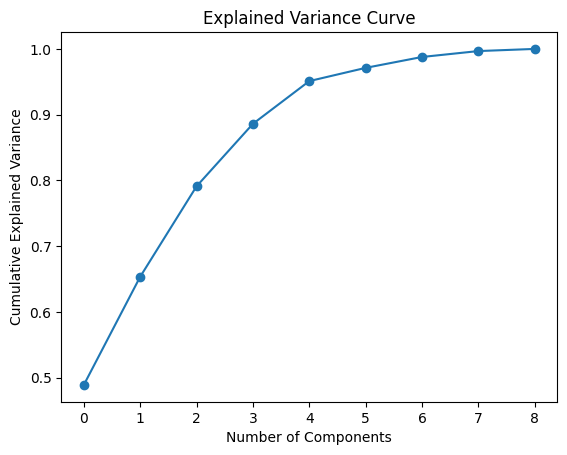

In [ ]:
# Selecting Optimal Number of Components
explained_variance = pca.explained_variance_ratio_

# Cumulative variance
cum_var = np.cumsum(explained_variance)

plt.plot(cum_var, marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance Curve')
plt.show()

In [ ]:
pca = PCA(n_components=0.9)
df_pca = pca.fit_transform(df_scaled)

In [ ]:
# Interpreting Principal Components
loadings = pd.DataFrame(
    pca.components_,
    columns=df.columns[1:],  # exclude 'country'
    index=[f'PC{i+1}' for i in range(pca.n_components_)]
)

loadings

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
PC1,-0.419443,0.242616,0.165009,0.104202,0.409415,-0.222526,0.426822,-0.404530,0.405166
PC2,0.073348,0.588411,-0.146887,0.740034,-0.098691,-0.124250,-0.161888,0.044268,-0.160689
PC3,0.084502,-0.315113,0.682955,0.223213,-0.177098,-0.575167,-0.108076,0.045972,-0.036565
PC4,0.387524,0.210441,0.312886,-0.017005,0.447997,0.212704,-0.208106,0.439500,0.474278
PC5,-0.222933,0.006384,0.544926,0.211376,-0.145996,0.723701,0.079041,-0.143059,-0.192001


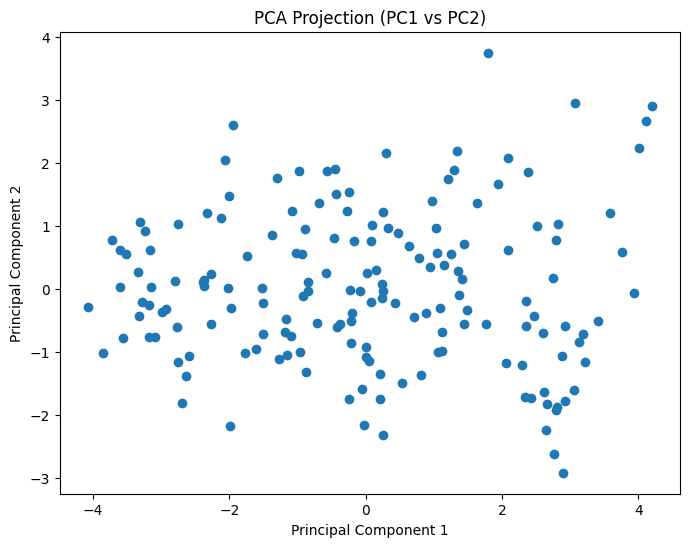

In [ ]:
# Visualizing PCA Space
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection (PC1 vs PC2)')
plt.show()

# Clustering with K-Means

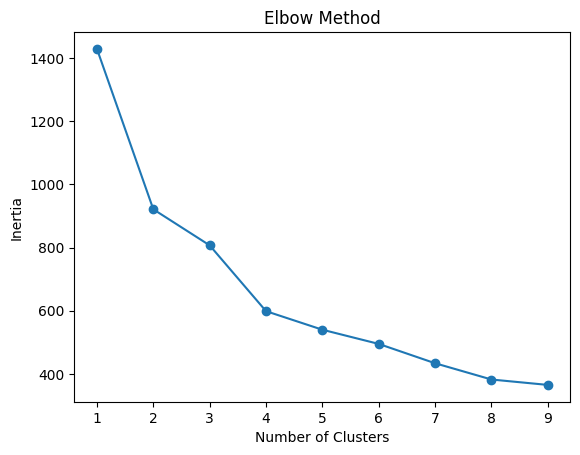

In [ ]:
# Finding Optimal Number of Clusters (k)
from sklearn.cluster import KMeans

# Elbow Method - Measures inertia (WCSS) - lower is better.
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(df_pca)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

k=4 looks like the elbow point.

In [ ]:
# Silhouette Score
from sklearn.metrics import silhouette_score

for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(df_pca)
    score = silhouette_score(df_pca, labels)
    print(f"k={k}, Silhouette Score={score}")

k=2, Silhouette Score=0.3042270387009291
k=3, Silhouette Score=0.2573526505135918
k=4, Silhouette Score=0.2936005988106999
k=5, Silhouette Score=0.2749235509861556
k=6, Silhouette Score=0.2818567917516468
k=7, Silhouette Score=0.2651200273324763
k=8, Silhouette Score=0.26855579280480685
k=9, Silhouette Score=0.26111151332698196


k=2, has the best score.

Best Overall Choice: k = 4

1) Strong elbow at k = 4.
2) High silhouette score (close to best).
3) Better segmentation granularity than k=2.
4) More meaningful for policy insights.

In [ ]:
# Apply K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(df_pca)

df['cluster'] = clusters

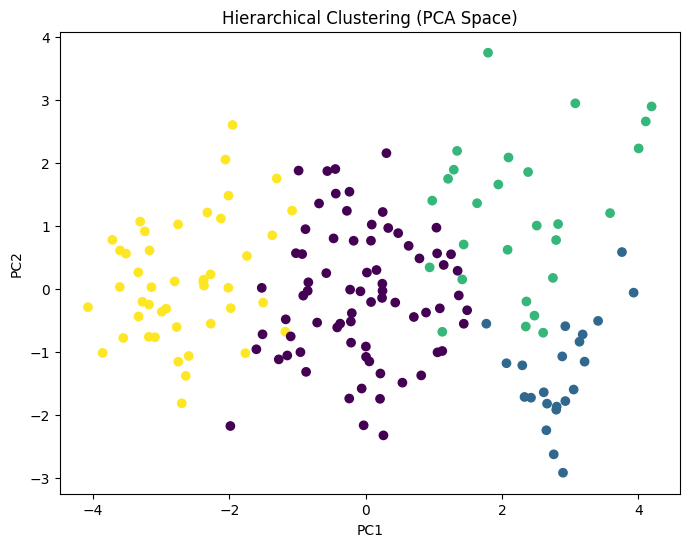

In [ ]:
# Visualize Clusters in PCA Space
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1], c=df['cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clustering (PCA Space)')
plt.show()

In [ ]:
# Cluster Profiling
cluster_profile = df.groupby('cluster').mean(numeric_only=True)
cluster_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
cluster,,,,,,,,,
0,24.369863,35.299849,6.376712,44.688574,10290.000000,7.703575,72.090411,2.391644,5286.054795
1,4.722727,36.018182,10.274091,34.645455,38560.681818,1.438636,80.631818,1.800000,31905.000000
2,8.459259,72.125000,5.899259,64.100000,33337.222222,4.791481,77.362963,1.858519,20791.481481
3,92.984444,28.602444,6.301111,42.306667,3539.844444,10.144111,59.456667,5.054611,1766.711111


In [ ]:
# List countries per cluster
df.groupby('cluster')['country'].apply(list)

,country
cluster,
0,"[Albania, Algeria, Antigua and Barbuda, Argent..."
1,"[Australia, Austria, Bahamas, Canada, Denmark,..."
2,"[Bahrain, Belgium, Brunei, Cyprus, Czech Repub..."
3,"[Afghanistan, Angola, Benin, Burkina Faso, Bur..."


In [ ]:
# Find representative country (closest to centroid)
centroids = kmeans.cluster_centers_

# distance from centroid
df['distance'] = np.linalg.norm(df_pca - centroids[df['cluster']], axis=1)

# representative country per cluster
df.loc[df.groupby('cluster')['distance'].idxmin()][['country','cluster']]

,country,cluster
76,Jamaica,0
158,United Kingdom,1
11,Bahrain,2
94,Malawi,3


# Clustering with Hierarchical Method

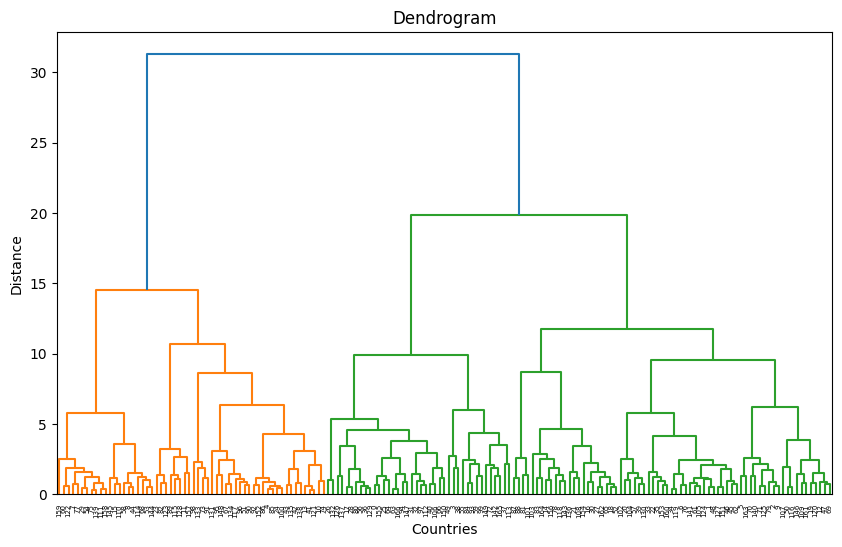

In [ ]:
# Visualize Dendrogram
import scipy.cluster.hierarchy as sch

plt.figure(figsize=(10,6))
dendrogram = sch.dendrogram(sch.linkage(df_pca, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Countries')
plt.ylabel('Distance')
plt.show()

In [ ]:
# Apply Hierarchical Clustering
from sklearn.cluster import AgglomerativeClustering

hc = AgglomerativeClustering(n_clusters=3, linkage='ward')
hc_labels = hc.fit_predict(df_pca)

df['hc_cluster'] = hc_labels

The dendrogram shows a clear separation with the largest vertical gap between linkage distances around 20. Cutting the tree at this level results in 3 distinct clusters, which are well-separated and avoid both over- and under-segmentation. These clusters are meaningful as they align with real-world categories of developed, developing, and underdeveloped countries, making the choice of k = 3 both data-driven and practically relevant.

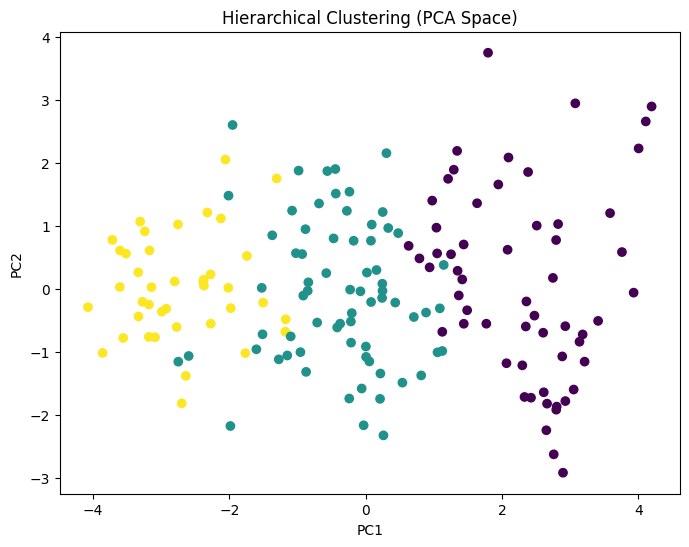

In [ ]:
# Visualize Clusters in PCA Space
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1], c=df['hc_cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Hierarchical Clustering (PCA Space)')
plt.show()

In [ ]:
# Cluster Profiling
hc_profile = df.drop('country', axis=1).groupby('hc_cluster').mean()
hc_profile

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,cluster,distance
hc_cluster,,,,,,,,,,,
0,7.451724,53.965086,7.719483,51.198276,32655.862069,2.993103,78.393103,1.810517,23275.172414,1.310345,1.611836
1,30.394203,33.118536,6.384203,45.340086,8867.246377,8.266391,70.528261,2.594493,4411.608696,0.260870,1.809983
2,94.155000,29.715500,6.153000,39.025000,3825.575000,10.897125,59.690000,5.194937,1857.575000,2.925000,1.843870


In [ ]:
# Identify Countries per Cluster
df.groupby('hc_cluster')['country'].apply(list)

,country
hc_cluster,
0,"[Antigua and Barbuda, Australia, Austria, Baha..."
1,"[Albania, Algeria, Argentina, Armenia, Azerbai..."
2,"[Afghanistan, Angola, Benin, Burkina Faso, Bur..."


# Clustering with DBSCAN

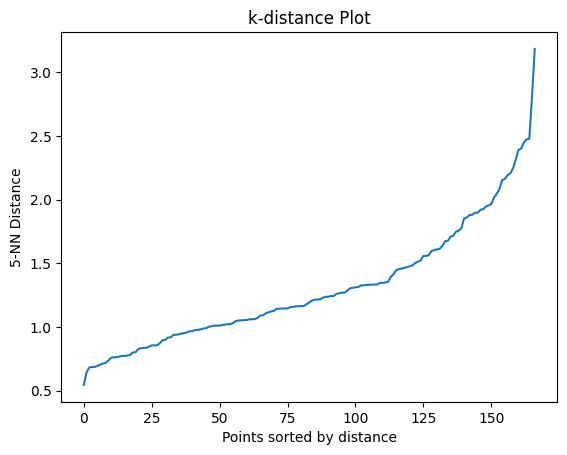

In [ ]:
# Finding Optimal eps
from sklearn.neighbors import NearestNeighbors

neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(df_pca)

distances, indices = neighbors_fit.kneighbors(df_pca)

# Sort distances
distances = np.sort(distances[:, 4])  # 5th neighbor
plt.plot(distances)
plt.xlabel('Points sorted by distance')
plt.ylabel('5-NN Distance')
plt.title('k-distance Plot')
plt.show()

In [ ]:
# Apply DBSCAN
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=1.5, min_samples=5)  # adjust eps based on plot
db_labels = dbscan.fit_predict(df_pca)

df['db_cluster'] = db_labels

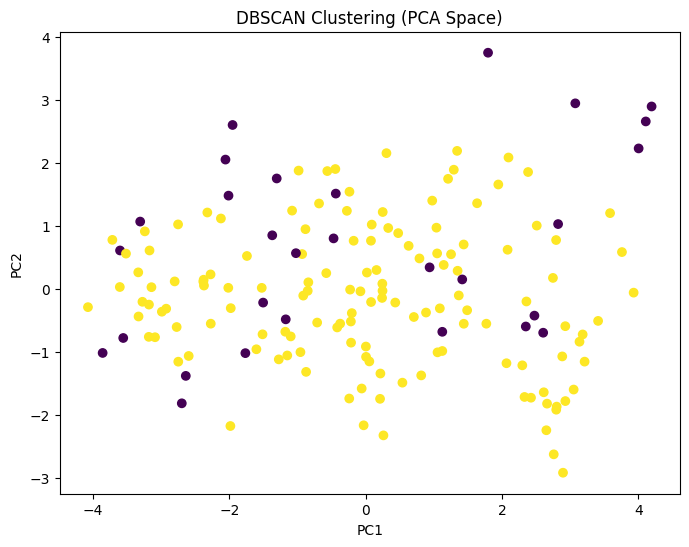

In [ ]:
# Visualize Clusters (PCA Space)
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:,0], df_pca[:,1], c=df['db_cluster'])
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('DBSCAN Clustering (PCA Space)')
plt.show()

In [ ]:
# Identify Noise Points
noise_points = df[df['db_cluster'] == -1]
noise_points[['country']]

,country
3,Angola
23,Brunei
37,"Congo, Dem. Rep."
38,"Congo, Rep."
49,Equatorial Guinea
55,Gabon
72,Iraq
73,Ireland
81,Kiribati
82,Kuwait


# Evaluation metrics

In [ ]:
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

def evaluate_clustering(data, labels):

    # number of unique clusters
    n_clusters = len(set(labels))

    if n_clusters < 2:
        return {
            "Silhouette": "Not valid",
            "Davies-Bouldin": "Not valid",
            "Calinski-Harabasz": "Not valid"
        }

    return {
        "Silhouette": silhouette_score(data, labels),
        "Davies-Bouldin": davies_bouldin_score(data, labels),
        "Calinski-Harabasz": calinski_harabasz_score(data, labels)
    }

# K-Means
kmeans_metrics = evaluate_clustering(df_pca, df['cluster'])

# Hierarchical
hc_metrics = evaluate_clustering(df_pca, df['hc_cluster'])

# DBSCAN (exclude noise)
mask = df['db_cluster'] != -1

dbscan_data = df_pca[mask]
dbscan_labels = df.loc[mask, 'db_cluster']

dbscan_metrics = evaluate_clustering(dbscan_data, dbscan_labels)

print("KMeans:", kmeans_metrics)
print("Hierarchical:", hc_metrics)
print("DBSCAN:", dbscan_metrics)

KMeans: {'Silhouette': np.float64(0.2936005988106999), 'Davies-Bouldin': np.float64(1.1921161997509213), 'Calinski-Harabasz': np.float64(75.43458768498253)}
Hierarchical: {'Silhouette': np.float64(0.24641649126149595), 'Davies-Bouldin': np.float64(1.364265056670105), 'Calinski-Harabasz': np.float64(75.93368673218154)}
DBSCAN: {'Silhouette': 'Not valid', 'Davies-Bouldin': 'Not valid', 'Calinski-Harabasz': 'Not valid'}


# Interpret Results & Propose Recommendations

**Hierarchical Clustering** identified three broad development segments: developed, developing, and underdeveloped economies. **K-Means** provided a more granular view by further splitting developed countries into advanced developed economies and trade-oriented developed economies. This suggests that while three clusters are sufficient for strategic policy planning, a four-cluster solution may be useful when designing specialized interventions for economically advanced nations.

**Segment 1: Developed Economies**

Profile :
*   Highest income (~32,656)
*   Highest GDP per capita (~23,275)
*   Highest life expectancy (~78.4 years)
*   Lowest child mortality (~7.5)
*   Lowest fertility (~1.81)

K-Means Insight :-
This segment is further divided into:

**Cluster 1: Advanced Developed Nations**

*   Highest income (~38,561)
*   Highest health spending (~10.27%)
*   Lower trade dependence

**Cluster 2: Trade-Oriented Developed Nations**

*   Strong exports (~72%)
*   Strong imports (~64%)
*   High income and GDP
*   More globally integrated economies

Policy Recommendations :

*   Promote innovation and R&D
*   Support sustainable growth initiatives
*   Address aging populations
*   Invest in advanced healthcare and technology

**Segment 2: Developing Economies**

Profile :

*   Moderate income (~8,867)
*   Moderate GDP (~4,412)
*   Life expectancy ~70.5 years
*   Child mortality ~30.4

Corresponds to K-Means Cluster 0

Policy Recommendations :

*   Expand healthcare access
*   Improve educational outcomes
*   Develop transportation and digital infrastructure
*   Encourage industrialization and higher-value exports







**Segment 3: Underdeveloped Economies**

Profile :

*   Lowest income (~3,826)
*   Lowest GDP (~1,858)
*   Highest child mortality (~94)
*   Lowest life expectancy (~59.7)
*   Highest fertility (~5.19)

Corresponds to K-Means Cluster 3.

Policy Recommendations :

*   Prioritize basic healthcare and vaccination programs
*   Improve maternal and child health
*   Expand clean water and sanitation infrastructure
*   Reduce poverty and food insecurity
*   Increase access to primary education

**DBSCAN** identified a set of countries as outliers, including both some of the world's wealthiest nations (e.g., Qatar, Singapore, Luxembourg, and the United Arab Emirates) and some of the most socio-economically challenged countries (e.g., Democratic Republic of Congo, Liberia, Sierra Leone, and Sudan). This indicates that these countries possess highly distinctive characteristics that set them apart from broader development groups. As a result, they may require tailored policy interventions rather than strategies designed for the general country segments identified through K-Means and Hierarchical Clustering.

# Business Questions

**1. If Standard Scaling was skipped, which features (e.g., gdpp vs. life_expec) would unfairly dominate the clustering distance calculation?**

If Standard Scaling is skipped, features with larger numerical ranges, such as gdpp and income, would dominate the distance calculations used in clustering. Features with smaller ranges, such as life_expec or health, would contribute very little, causing clusters to form primarily based on economic magnitude rather than overall socio-economic similarity.

**2. Why might capping extreme high/low values (like max child_mort) be counterproductive when the goal is to identify countries in the most critical need of aid?**

Extreme values in features like child_mort often represent countries in severe socio-economic distress. Capping these values may reduce the visibility of genuinely vulnerable countries and weaken the model’s ability to identify nations most in need of aid and intervention. In development analysis, such extremes are often meaningful rather than errors.

**3. If K-Means yields a very high Silhouette Score, what does this imply about the separation and cohesion of the identified country segments?**

A high Silhouette Score indicates that:

*   Countries within the same cluster are highly similar (high cohesion).
*   Different clusters are clearly separated (high separation).

This suggests the identified country segments are meaningful and well-structured.

**4. What unique policy insight does a Hierarchical Clustering Dendrogram offer that a K-Means scatter plot does not, regarding the relationships between clusters?**

A dendrogram not only shows the final clusters but also reveals the hierarchical relationships between clusters, including:

*   Which clusters are most similar.
*   At what distance clusters merge.
*   How country groups progressively combine.

This provides deeper insight into the structure of country relationships than a simple K-Means scatter plot.

**5. Segment A has high income and high health spend. Segment B has low income and low health spend. What distinct policy goal should be set for Segment A vs. Segment B?**

Distinct Policy Goals for Segment A vs Segment B
Segment	Policy Goal :


*   Segment A (high income, high health spending)	: Focus on innovation, sustainability, aging populations, and advanced healthcare efficiency.
*   Segment B (low income, low health spending) : Prioritize basic healthcare access, disease prevention, nutrition, and healthcare infrastructure development.





**6. What is the business purpose of identifying the country closest to a cluster's centroid (the "representative country") for policy communication?**

The country closest to a cluster centroid acts as a representative example of that segment. This helps:

*   Simplify communication of cluster characteristics
Create relatable policy case studies.
*   Demonstrate how development strategies may apply to similar countries within the cluster.






**7. A cluster profile shows high average exports and imports but low gdpp. What is the immediate, tailored policy recommendation for this "Mid-Income Traders" segment?**

A cluster with high exports and imports but low GDP per capita suggests economies that are globally connected but not translating trade into broad economic prosperity.

Recommended Policy:

*   Strengthen domestic value addition and industrial capacity.
*   Invest in manufacturing, skills development, and trade competitiveness.
*   Reduce dependency on low-value exports.
*   Improve infrastructure and supply-chain efficiency to convert trade activity into sustainable income growth.





